# SAP HANA Cloud KGE + AI Core — GraphRAG 질의 실습

이 notebook에서는 자연어 질문을 HANA Cloud Knowledge Graph에 던지는 **GraphRAG 파이프라인**을 직접 실행해봅니다.

실습이 끝나면 다음을 할 수 있게 됩니다:

- GraphRAG 파이프라인의 전체 흐름을 이해합니다.
- SAP AI Core를 통해 LLM(gpt-4o)을 호출할 수 있습니다.
- `langchain-hana`의 `HanaRdfGraph`와 `HanaSparqlQAChain`을 사용할 수 있습니다.
- 자연어 질문을 입력하고 그래프 기반 답변을 받을 수 있습니다.

---

## 1. GraphRAG란?

### GraphRAG 파이프라인 흐름

```
자연어 질문
    │
    ▼
① LLM (gpt-4o)
   그래프 스키마(온톨로지)를 참고해서
   SPARQL 쿼리를 자동 생성
    │
    ▼
② HANA Cloud KGE
   SPARQL 쿼리 실행 → 그래프에서 관련 데이터 검색
    │
    ▼
③ LLM (gpt-4o)
   검색된 그래프 데이터를 바탕으로
   자연어 답변 생성
    │
    ▼
최종 답변
```

<div style="border-left: 4px solid #4c8bf5; padding: 8px 12px; background: #f6f9ff; border-radius: 6px;">
  <b>핵심: SPARQL을 직접 쓰지 않아도 됩니다</b><br/>
  이전 실습(<code>01_sparql_basics.ipynb</code>)에서 직접 작성했던 SPARQL 쿼리를,
  이제 LLM이 자동으로 생성합니다.
  그래프 스키마(어떤 클래스와 프로퍼티가 있는지)만 LLM에게 알려주면,
  LLM이 적절한 SPARQL을 만들어 HANA Cloud에 실행합니다.
</div>

---

## 2. Setup and Configuration

### 패키지 소개

이 notebook에서 사용하는 패키지입니다.

#### hdbcli
SAP HANA Cloud에 접속하기 위한 공식 Python 드라이버입니다. SPARQL 실행도 이 드라이버를 통해 이루어집니다.

#### langchain-hana
LangChain의 SAP HANA Cloud 통합 패키지입니다. `HanaRdfGraph`(스키마 추출)와 `HanaSparqlQAChain`(GraphRAG 파이프라인)을 제공합니다.

#### generative-ai-hub-sdk
SAP AI Core에 접속하기 위한 SDK입니다. `init_llm()`으로 gpt-4o 등 LLM을 초기화합니다.

### 패키지 설치

> **Note:** 패키지 설치 후에는 Jupyter Notebook 커널을 반드시 재시작해야 합니다.

In [ ]:
%pip install hdbcli                      # HANA Cloud 연결
%pip install langchain-hana              # GraphRAG 파이프라인
%pip install generative-ai-hub-sdk[ALL]  # SAP AI Core
%pip install python-dotenv         # .env 파일 로드


#### 커널 재시작

패키지 설치 후 아래 메뉴에서 커널을 재시작하세요:

- Jupyter Notebook: **Kernel → Restart Kernel**
- VS Code: 우측 상단 커널 선택 버튼 → **Restart**

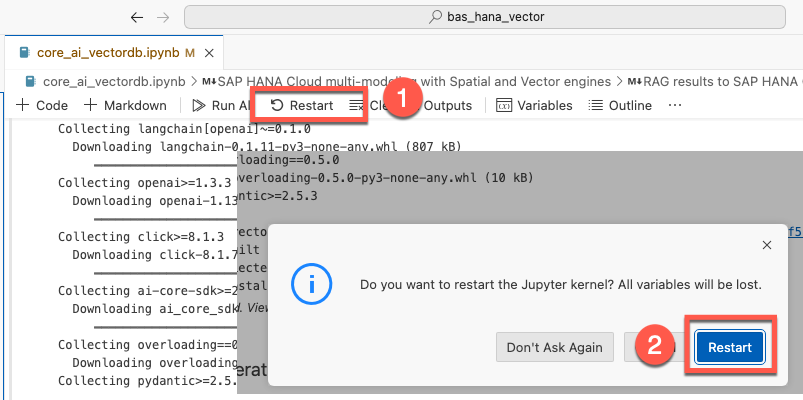

### 연결 정보 설정

아래 셀에서 연결 정보를 입력합니다. **여기만 수정하면 됩니다.**

연결 정보는 워크숍 당일 발표자가 배포합니다.

In [ ]:
# ============================================================
# 연결 정보 설정 — 루트의 .env 파일에서 자동으로 읽어옵니다
# .env 파일이 없으면 .env.example 을 복사해서 값을 채워주세요
#   cp .env.example .env
# ============================================================
from dotenv import load_dotenv
import os

load_dotenv()

HANA_HOST     = os.getenv("HANA_HOST", "")
HANA_PORT     = int(os.getenv("HANA_PORT", 443))
HANA_USER     = os.getenv("HANA_USER", "")
HANA_PASSWORD = os.getenv("HANA_PASSWORD", "")
MY_NUMBER     = os.getenv("MY_NUMBER", "")

MOVIES_GRAPH          = f"kgdocu_movies_{MY_NUMBER}"
MOVIES_ONTOLOGY_GRAPH = f"kgdocu_movies_ontology_{MY_NUMBER}"

print(f"Host  : {HANA_HOST}")
print(f"User  : {HANA_USER}")
print(f"Number: {MY_NUMBER}")
print(f"Graph : {MOVIES_GRAPH}")

### HANA Cloud 연결

In [ ]:
from hdbcli import dbapi

connection = dbapi.connect(
    address=HANA_HOST,
    port=HANA_PORT,
    user=HANA_USER,
    password=HANA_PASSWORD,
    autocommit=True,
    sslValidateCertificate=False,
)

cursor = connection.cursor()
cursor.execute("SELECT * FROM SYS.DUMMY")
print("연결 성공!")
print(f"그래프: {MOVIES_GRAPH}")

### AI Core LLM 연결

<div style="border-left: 4px solid #4c8bf5; padding: 8px 12px; background: #f6f9ff; border-radius: 6px;">
  <b>SAP AI Core와 LLM</b><br/>
  SAP AI Core는 여러 LLM(gpt-4o, Claude 등)을 하나의 API로 사용할 수 있는 SAP의 AI 플랫폼입니다.
  <code>generative-ai-hub-sdk</code> 패키지를 통해 LangChain 인터페이스로 LLM을 호출합니다.
  오늘 실습에서는 <b>gpt-4o</b>를 사용합니다.
</div>

In [ ]:
from gen_ai_hub.proxy.langchain.openai import ChatOpenAI
from gen_ai_hub.proxy.core.proxy_clients import get_proxy_client

proxy_client = get_proxy_client("gen-ai-hub")
llm = ChatOpenAI(proxy_model_name="gpt-4o", proxy_client=proxy_client)

# 연결 테스트
test_response = llm.invoke("Say 'AI Core connected' in Korean in one sentence.")
print(test_response.content)

---

## 3. HanaRdfGraph — 그래프 스키마 불러오기

`HanaRdfGraph`는 HANA Cloud KGE에 연결하고, 그래프의 스키마(온톨로지)를 불러오는 클래스입니다.

LLM이 SPARQL을 생성하려면 **어떤 클래스와 프로퍼티가 있는지** 알아야 합니다. `HanaRdfGraph`가 이 정보를 자동으로 준비해줍니다.

<div style="border-left: 4px solid #4c8bf5; padding: 8px 12px; background: #f6f9ff; border-radius: 6px;">
  <b><code>ontology_uri</code></b><br/>
  온톨로지가 저장된 Named Graph URI를 지정합니다. <code>HanaRdfGraph</code>가 이 그래프에서 클래스, 프로퍼티, 관계 구조를 읽어 LLM 프롬프트에 포함합니다.
  추출된 스키마는 SPARQL 생성의 가이드가 됩니다.
</div>

In [ ]:
from langchain_hana import HanaRdfGraph

graph = HanaRdfGraph(
    connection=connection,
    graph_uri=MOVIES_GRAPH,
    ontology_uri=MOVIES_ONTOLOGY_GRAPH,
)

print("그래프 스키마 추출 완료")
print()
print("=== 추출된 스키마 ===")
print(graph.get_schema)

위에서 출력된 스키마가 LLM에게 전달되는 정보입니다. 클래스(`Film`, `Actor`, `Director` 등)와 각각의 프로퍼티가 나열됩니다.

LLM은 이 스키마를 참고해서 자연어 질문에 맞는 SPARQL을 생성합니다.

---

## 4. HanaSparqlQAChain — GraphRAG 파이프라인 구성

`HanaSparqlQAChain`은 자연어 질문 → SPARQL 생성 → HANA 실행 → 자연어 답변의 전체 파이프라인을 하나의 체인으로 묶은 클래스입니다.

In [ ]:
from langchain_hana import HanaSparqlQAChain

chain = HanaSparqlQAChain.from_llm(
    llm=llm,
    graph=graph,
    allow_dangerous_requests=True,
    verbose=True,   # SPARQL 생성 과정을 출력합니다
)

print("GraphRAG 파이프라인 준비 완료")

---

## 5. GraphRAG 질의 실습

### 5-1. 첫 번째 질문 — 이전 실습 연결

`01_sparql_basics.ipynb` 종합 실습에서 여러분이 직접 SPARQL로 만들었던 질문입니다.

**이번에는 자연어로 그냥 질문합니다. LLM이 SPARQL을 자동으로 만들어줍니다.**

In [ ]:
question = "The Matrix를 감독한 감독은 누구인가요?"

output = chain.invoke(question)
print("\n=== 최종 답변 ===")
print(output["result"])

> **`verbose=True`** 로 설정했기 때문에, 위 출력에서 LLM이 생성한 SPARQL 쿼리도 함께 볼 수 있습니다.
> 이전 실습에서 여러분이 직접 작성한 쿼리와 비교해보세요.

### 5-2. 추가 질문들

In [ ]:
question = "Blade Runner에 출연한 배우는 누구누구인가요?"

output = chain.invoke(question)
print("\n=== 최종 답변 ===")
print(output["result"])

In [ ]:
question = "Keanu Reeves가 출연한 영화 목록을 알려주세요."

output = chain.invoke(question)
print("\n=== 최종 답변 ===")
print(output["result"])

> **참고 — GPT-4o의 한국어 응답 불안정성**
>
> GPT-4o는 한국어 질문에 대해 간혹 "관련 정보를 찾을 수 없습니다"라고 답하는 경우가 있습니다.
> SPARQL이 정상 실행되어 결과가 있는 경우에도 발생할 수 있습니다.
>
> **원인:** SPARQL 결과를 받은 LLM이 한국어 컨텍스트에서 답변을 생성할 때 불안정하게 동작하는 GPT-4o의 특성입니다.
>
> **해결 방법:**
> - 셀을 다시 실행해보세요 (재실행 시 정상 응답하는 경우가 많습니다)
> - 영어로 질문하면 안정적으로 답변합니다 (예: "Who directed The Matrix?")
> - Claude 모델 사용 시 이런 문제가 거의 발생하지 않습니다

---

## 6. SPARQL 직접 확인하기 — 왜 결과가 없을까?

GraphRAG는 항상 올바른 답을 주지 않습니다. **LLM이 생성한 SPARQL이 잘못됐을 수 있기 때문입니다.**

예를 들어 이런 질문을 해봅시다:

> **"액션 장르 영화를 모두 알려주세요."**

아무 결과가 없거나 이상한 답이 나올 수 있습니다. 왜 그럴까요?
verbose 출력에서 LLM이 생성한 SPARQL을 직접 확인해봅시다.

In [ ]:
question = "액션 장르 영화를 모두 알려주세요."
output = chain.invoke(question)

print("\n=== 최종 답변 ===")
print(output["result"])

위 출력에서 LLM이 생성한 SPARQL의 장르 필터 부분을 확인해보세요.

LLM은 보통 이런 SPARQL을 생성합니다:

```sparql
FILTER(?genreLabel = "Action")   -- 또는
FILTER(?genreLabel = "액션")
```

하지만 실제 데이터에서 장르 라벨은 **`"action film"`** 으로 저장되어 있습니다.
정확히 일치하지 않아서 결과가 없는 겁니다.

**해결 방법:** LLM에게 장르 검색 시 `CONTAINS` + `LCASE`를 사용하도록 지시합니다 → 7번에서 해결합니다.

---

## 7. 프롬프트 커스터마이징으로 문제 해결

GraphRAG 파이프라인에는 LLM이 두 번 호출됩니다:

| 단계 | 프롬프트 파라미터 | 역할 |
|------|------------------|------|
| ① SPARQL 생성 | `sparql_generation_prompt` | 자연어 → SPARQL 변환 규칙 지정 |
| ③ 답변 생성 | `qa_prompt` | SPARQL 결과 → 자연어 답변 형식 지정 |

방금 확인한 장르 검색 문제를 `sparql_generation_prompt`에 규칙을 추가해서 해결해봅니다.

### 7-1. SPARQL 생성 프롬프트 커스터마이징

`sparql_generation_prompt`에는 두 개의 변수가 필요합니다:
- `{schema}` — `HanaRdfGraph`가 추출한 온톨로지 (자동 주입)
- `{prompt}` — 사용자의 자연어 질문 (자동 주입)

장르 검색 문제를 해결하기 위해 두 가지 규칙을 추가합니다:
1. **한국어 장르명을 영어로 번역** (예: 액션 → action)
2. **`CONTAINS(LCASE(...), ...)`로 부분 매칭** — 정확한 라벨을 몰라도 검색 가능

In [ ]:
from langchain_core.prompts import PromptTemplate

# SPARQL 생성 프롬프트 커스터마이징
# {schema}와 {prompt} 두 변수는 반드시 포함해야 합니다
# f-string으로 MOVIES_GRAPH를 직접 주입해 LLM이 올바른 FROM 절을 생성하도록 합니다
custom_sparql_prompt = PromptTemplate(
    input_variables=["schema", "prompt"],
    template=f"""당신은 SAP HANA Cloud Knowledge Graph 전문가입니다.
아래 온톨로지 스키마를 참고하여 자연어 질문에 맞는 SPARQL SELECT 쿼리를 생성하세요.

규칙:
- SELECT 쿼리만 생성하세요 (INSERT, DELETE 금지)
- FROM 절에는 반드시 <{MOVIES_GRAPH}> 를 사용하세요
- PREFIX는 쿼리 맨 위에 선언하세요
- [중요] 프로퍼티 방향을 반드시 지키세요: ?director kg:directed ?film (감독→영화), ?actor kg:acted_in ?film (배우→영화)
- 장르 이름을 한국어로 입력받은 경우 영어로 번역하세요 (예: 액션 → action, 공상과학 → science fiction)
- 인물 이름(감독, 배우)을 한국어 발음으로 입력받은 경우 영어 이름으로 번역하세요 (예: 리들리 스캇 → Ridley Scott)
- 라벨 검색에는 FILTER(?label = "...") 대신 FILTER(CONTAINS(LCASE(?label), "..."))를 사용하세요
- 결과는 SPARQL 쿼리만 출력하세요 (설명 불필요)

온톨로지 스키마:
{{schema}}

질문: {{prompt}}

SPARQL 쿼리:"""
)

print("SPARQL 생성 프롬프트 준비 완료")

### 7-2. 답변 생성 프롬프트 커스터마이징

`qa_prompt`에는 두 개의 변수가 필요합니다:
- `{context}` — SPARQL 실행 결과 (자동 주입)
- `{prompt}` — 사용자의 원래 질문 (자동 주입)

In [ ]:
# 답변 생성 프롬프트 커스터마이징
# {context}와 {prompt} 두 변수는 반드시 포함해야 합니다
custom_qa_prompt = PromptTemplate(
    input_variables=["context", "prompt"],
    template="""아래 데이터는 Knowledge Graph에서 검색한 결과입니다.
이 데이터만을 근거로 질문에 한국어로 답하세요.
데이터에 없는 내용은 추측하지 마세요.
검색 결과에 나열된 항목은 빠짐없이 모두 포함하세요.

검색 결과:
{context}

질문: {prompt}

답변:"""
)

print("답변 생성 프롬프트 준비 완료")

### 7-3. 커스텀 프롬프트로 문제 재현 — 이번엔 결과가 나올까요?

In [ ]:
custom_chain = HanaSparqlQAChain.from_llm(
    llm=llm,
    graph=graph,
    allow_dangerous_requests=True,
    verbose=True,
    sparql_generation_prompt=custom_sparql_prompt,
    qa_prompt=custom_qa_prompt,
)

# 6번에서 결과가 없었던 바로 그 질문으로 다시 시도합니다
question = "액션 장르 영화를 모두 알려주세요."
output = custom_chain.invoke(question)

print("\n=== 최종 답변 ===")
print(output["result"])

> **참고 — GPT-4o의 답변 누락 문제**
>
> SPARQL이 올바르게 실행되어 컨텍스트에 3편이 모두 포함되어 있어도,
> GPT-4o가 일부 항목을 누락하거나 "정보 없음"으로 답하는 경우가 있습니다.
>
> 이는 GPT-4o의 오래된 버전에서 나타나는 한계로, 프롬프트 수정만으로는 완전히 해결되지 않습니다.
> 최신 모델일수록 이런 문제가 줄어듭니다.

---

## 정리

이 notebook에서 배운 내용을 정리합니다:

| 구성 요소 | 역할 |
|-----------|------|
| **SAP AI Core** | LLM(gpt-4o)을 호출하는 SAP AI 플랫폼 |
| **`HanaRdfGraph`** | HANA KGE 연결 + 스키마(온톨로지) 자동 추출 |
| **`HanaSparqlQAChain`** | 자연어 → SPARQL → HANA 실행 → 자연어 답변 파이프라인 |
| **온톨로지** | LLM이 SPARQL을 만들기 위해 참고하는 그래프 스키마 |

### GraphRAG vs. Vector RAG

| | Vector RAG | GraphRAG |
|--|------------|----------|
| **검색 방식** | 의미적 유사도 (벡터 거리) | 그래프 구조 탐색 (SPARQL) |
| **강점** | 비정형 텍스트, 의미 검색 | 명확한 관계, 다단계 연결 |
| **예시 질문** | "AI에 대해 설명해줘" | "X와 Y가 함께 출연한 영화는?" |
| **HANA Cloud** | Vector Engine | Knowledge Graph Engine |

SAP HANA Cloud는 두 엔진을 동시에 지원하므로, 데이터 성격에 따라 혼합해서 사용할 수 있습니다.